In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import sys
import time


In [2]:
url = "https://raw.githubusercontent.com/datasets/oil-prices/master/data/brent-daily.csv"
df = pd.read_csv(url)
df.rename(columns={'Date':'observation_date','Price':'price'}, inplace=True)
df['observation_date'] = pd.to_datetime(df['observation_date'])
df.set_index('observation_date', inplace=True)
df.sort_index(inplace=True)

In [3]:
df['lag_7'] = df['price'].shift(7)
df['rolling_mean_7'] = df['price'].rolling(7).mean()
df['rolling_std_7'] = df['price'].rolling(7).std()
df.dropna(inplace=True)


In [4]:
split = int(len(df) * 0.6)
train = df.iloc[:split]
test = df.iloc[split:]

In [5]:

try:
    predictions = pd.read_csv('arima_predictions.csv', index_col=0, parse_dates=True)['pred']
    print(" Loaded precomputed ARIMA predictions")
except:
    from statsmodels.tsa.arima.model import ARIMA
    history = train['price'].tolist()
    predictions = []

    total_steps = len(test)
    print(" Computing ARIMA predictions with progress:")

    for t in range(total_steps):
        model = ARIMA(history, order=(1,1,1))
        model_fit = model.fit()
        pred = model_fit.forecast()[0]
        predictions.append(pred)
        history.append(test['price'].iloc[t])


        progress = (t+1)/total_steps*100
        sys.stdout.write(f"\rProgress: {progress:.1f}%")
        sys.stdout.flush()

    predictions = pd.Series(predictions, index=test.index)
    predictions.to_csv('arima_predictions.csv')
    print("\n ARIMA computation completed and saved")

 Computing ARIMA predictions with progress:
Progress: 100.0%
 ARIMA computation completed and saved


In [18]:
features = ['price','lag_7','rolling_mean_7','rolling_std_7']
scaler = StandardScaler()
X_train = scaler.fit_transform(train[features])
X_test = scaler.transform(test[features])

iso = IsolationForest(contamination=0.03, random_state=42)
iso.fit(X_train)
test['iso_anomaly'] = (iso.predict(X_test) == -1)

print("Isolation Forest  completed")

Isolation Forest  completed


/tmp/ipykernel_662/3348241335.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['iso_anomaly'] = (iso.predict(X_test) == -1)


In [17]:

mean, std = train['price'].mean(), train['price'].std()
threshold_cusum = 4 * std
pos, neg = 0, 0
cusum = []
for x in test['price']:
    pos = max(0, pos + (x - mean))
    neg = min(0, neg + (x - mean))
    cusum.append(pos > threshold_cusum or abs(neg) > threshold_cusum)
test['cusum_anomaly'] = cusum
print("CUSUM  completed")


CUSUM  completed


/tmp/ipykernel_662/880706882.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['cusum_anomaly'] = cusum


In [19]:
residuals = test['price'] - predictions
threshold_arima = 2 * residuals.std()
test['arima_anomaly'] = abs(residuals) > threshold_arima

print("ARIMA anomaly detection completed")

ARIMA anomaly detection completed


/tmp/ipykernel_662/3685482245.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['arima_anomaly'] = abs(residuals) > threshold_arima


In [20]:
test['score'] = test[['arima_anomaly','iso_anomaly','cusum_anomaly']].sum(axis=1)
test['event'] = 'Normal'
test.loc[test['score']==1,'event'] = 'Weak'
test.loc[test['score']==2,'event'] = 'Warning'
test.loc[test['score']==3,'event'] = 'Crisis'

print("\n✅ Anomaly detection complete")
print(test['event'].value_counts())


Anomaly detection complete
event
Weak       2795
Warning    1042
Crisis      103
Normal        2
Name: count, dtype: int64


/tmp/ipykernel_662/791920379.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['score'] = test[['arima_anomaly','iso_anomaly','cusum_anomaly']].sum(axis=1)
/tmp/ipykernel_662/791920379.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['event'] = 'Normal'


/tmp/ipykernel_662/2744241383.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['event_plot'] = 'Normal'


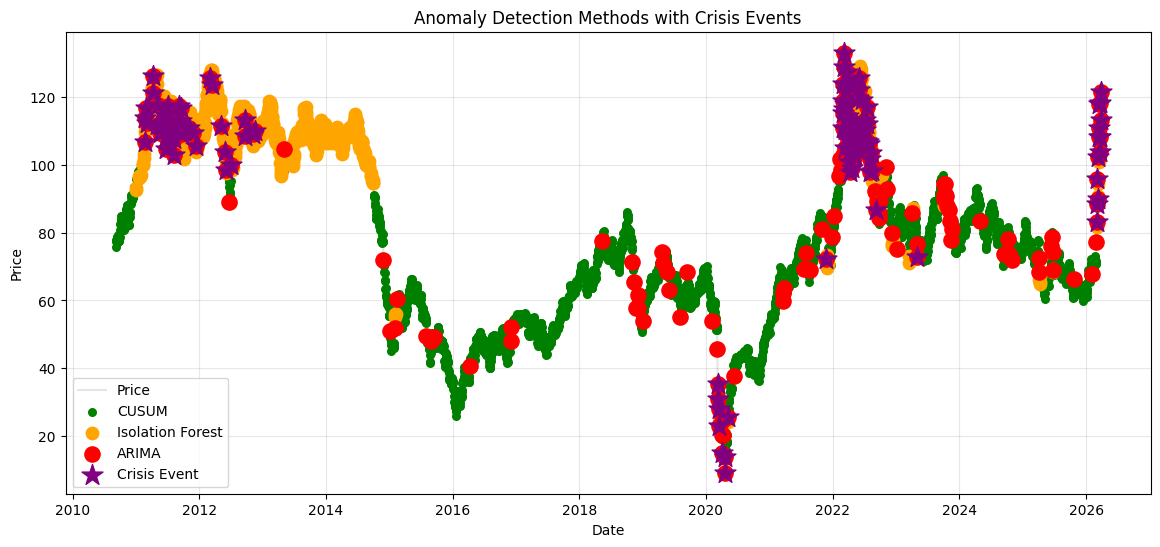

Total Data Points: 3942
ARIMA detections: 185
CUSUM detections: 3940
ISO detections: 1063
Crisis events detected: 103


In [25]:
import matplotlib.pyplot as plt


test['event_plot'] = 'Normal'
test.loc[test['score']==1, 'event_plot'] = 'Weak'
test.loc[test['score']==2, 'event_plot'] = 'Warning'
test.loc[test['score']==3, 'event_plot'] = 'Crisis'
plt.figure(figsize=(14,6))

plt.plot(test.index, test['price'], label='Price', color='black', alpha=0.1)
plt.scatter(test.index[test['cusum_anomaly']], test['price'][test['cusum_anomaly']],
            color='green', label='CUSUM', zorder=2, s=30)


plt.scatter(test.index[test['iso_anomaly']], test['price'][test['iso_anomaly']],
            color='orange', label='Isolation Forest', zorder=3, s=80)


plt.scatter(test.index[test['arima_anomaly']], test['price'][test['arima_anomaly']],
            color='red', label='ARIMA', zorder=5, s=120)

crisis_points = test[test['event_plot'] == 'Crisis']
plt.scatter(crisis_points.index, crisis_points['price'],
            color='purple', marker='*', s=250, label='Crisis Event', zorder=6)

plt.title("Anomaly Detection Methods with Crisis Events")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


print(f"Total Data Points: {len(test)}")
print(f"ARIMA detections: {test['arima_anomaly'].sum()}")
print(f"CUSUM detections: {test['cusum_anomaly'].sum()}")
print(f"ISO detections: {test['iso_anomaly'].sum()}")
print(f"Crisis events detected: {crisis_points.shape[0]}")

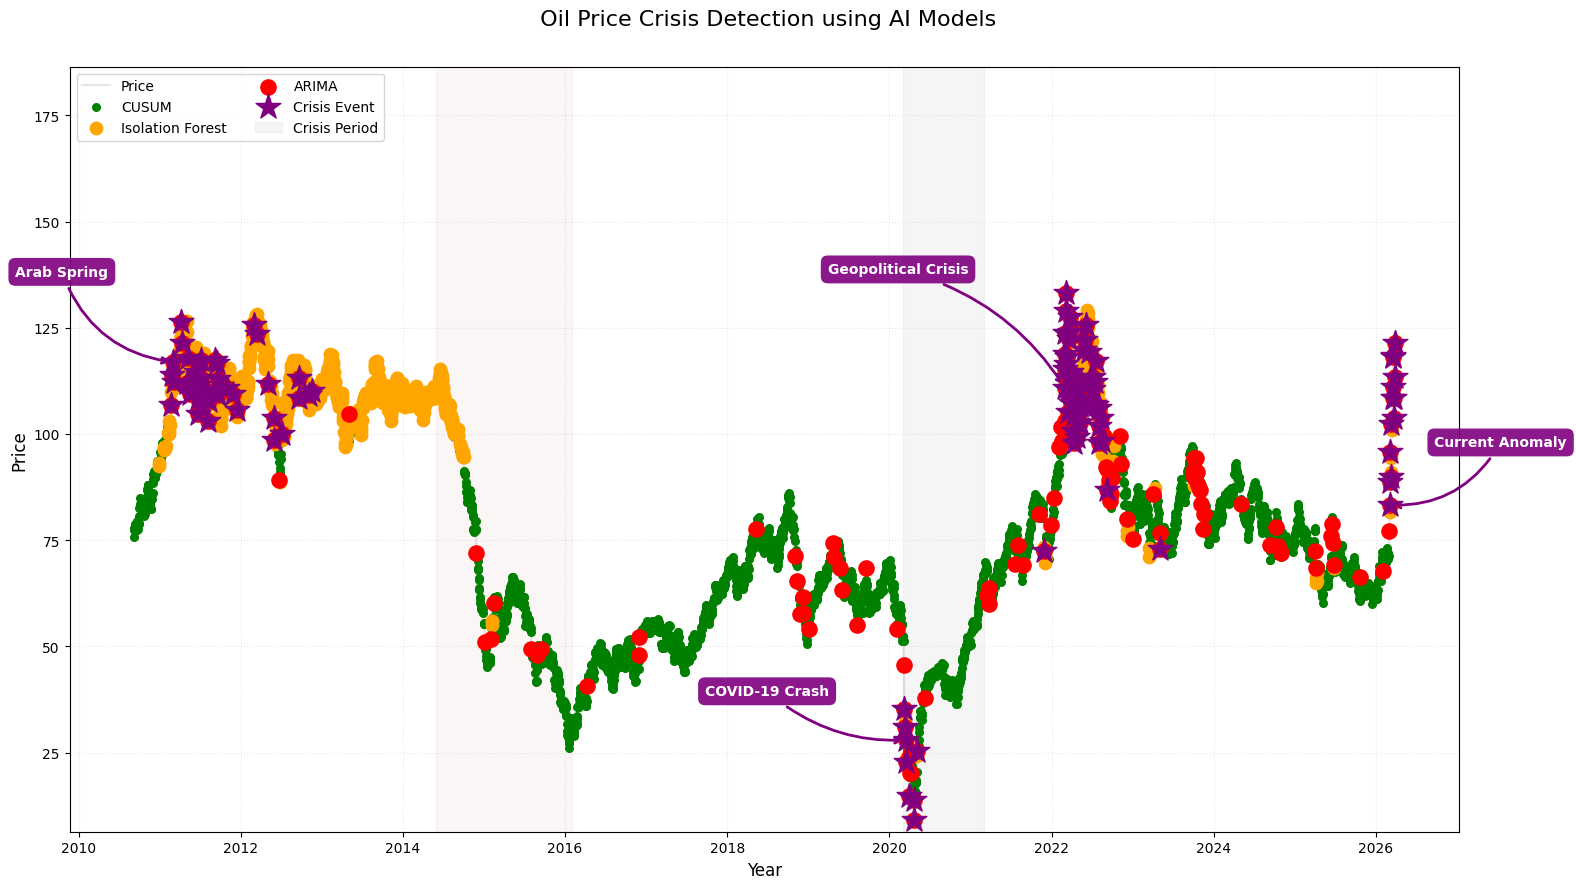

In [31]:
import matplotlib.pyplot as plt
import pandas as pd


plt.figure(figsize=(16, 9))
plt.plot(test.index, test['price'], label='Price', color='black', alpha=0.1, zorder=1)


plt.scatter(test.index[test['cusum_anomaly']], test['price'][test['cusum_anomaly']],
            color='green', label='CUSUM', zorder=2, s=30)
plt.scatter(test.index[test['iso_anomaly']], test['price'][test['iso_anomaly']],
            color='orange', label='Isolation Forest', zorder=3, s=80)
plt.scatter(test.index[test['arima_anomaly']], test['price'][test['arima_anomaly']],
            color='red', label='ARIMA', zorder=4, s=120)

crisis_points = test[test['event_plot'] == 'Crisis']
plt.scatter(crisis_points.index, crisis_points['price'],
            color='purple', marker='*', s=350, label='Crisis Event', zorder=5)

plt.axvspan(pd.to_datetime('2020-03-01'), pd.to_datetime('2021-03-01'), color='gray', alpha=0.08, label='Crisis Period')
plt.axvspan(pd.to_datetime('2014-06-01'), pd.to_datetime('2016-02-01'), color='brown', alpha=0.04)


event_configs = {
    '2011-03-01': ('Arab Spring', -80, 60, 0.3),
    '2020-03-15': ('COVID-19 Crash', -100, 30, 0.2),
    '2022-02-24': ('Geopolitical Crisis', -120, 80, -0.2),
    '2026-01-10': ('Current Anomaly', 80, 40, -0.3)
}

for date_str, (text, ox, oy, rad) in event_configs.items():
    target_date = pd.to_datetime(date_str)
    if not crisis_points.empty:
        idx = crisis_points.index.get_indexer([target_date], method='nearest')[0]
        actual_date = crisis_points.index[idx]
        actual_price = crisis_points.iloc[idx]['price']

        plt.annotate(
            text,
            xy=(actual_date, actual_price),
            xytext=(ox, oy),
            textcoords='offset points',
            ha='center',
            va='bottom',
            fontweight='bold',
            color='white',
            fontsize=10,
            bbox=dict(boxstyle='round,pad=0.5', fc='purple', alpha=0.9, ec='none'),
            arrowprops=dict(
                arrowstyle='->',
                connectionstyle=f"arc3,rad={rad}",
                color='purple',
                lw=2)
        )


plt.title(" Oil Price Crisis Detection using AI Models", fontsize=16, pad=30)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Price", fontsize=12)


plt.ylim(test['price'].min() * 0.7, test['price'].max() * 1.4)

plt.legend(loc='upper left', frameon=True, ncol=2)
plt.grid(True, linestyle=':', alpha=0.3)
plt.tight_layout()

plt.show()